In [118]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,accuracy_score,
                             precision_score,recall_score,f1_score,classification_report,roc_auc_score)

In [119]:

path = kagglehub.dataset_download("venky73/spam-mails-dataset")
files = os.listdir(path)
for file in files:
    if file.endswith(".csv"):
        path = os.path.join(path, file)
        break
df = pd.read_csv(path)
#df = pd.read_csv("../kaggle_files/Spam mail Dataset/spam_ham_dataset.csv")

Using Colab cache for faster access to the 'spam-mails-dataset' dataset.


In [108]:
df.head(5)

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [120]:
X = df['text']
Y = df['label_num']

In [110]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
x_train.str.strip()

,text
5132,Subject: april activity surveys\r\nwe are star...
2067,Subject: message subject\r\nhey i ' am julie ^...
4716,Subject: txu fuels / sds nomination for may 20...
4710,Subject: re : richardson volumes nov 99 and de...
2268,Subject: a new era of online medical care .\r\...
...,...
4426,Subject: re : ena sales on hpl\r\nlast that i ...
466,Subject: tenaska iv\r\nbob :\r\ni understand f...
3092,"Subject: broom , bristles up , flew\r\nbe diff..."
3772,Subject: calpine daily gas nomination ( weeken...


In [121]:

vector =TfidfVectorizer()
x_train_vect = vector.fit_transform(x_train)
x_test_vect = vector.transform(x_test)

In [127]:
param_grid = {
    'n_estimators':,
    'max_depth': [10, 20, None],
    'min_samples_split': ,
    'class_weight': ['balanced',None ]
}

SyntaxError: expression expected after dictionary key and ':' (1066606500.py, line 2)

In [126]:
#model = LogisticRegression(class_weight='balanced')
model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(x_train_vect, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

pred = grid_search.predict(x_test_vect)

ValueError: Parameter grid for parameter 'n_estimators' need to be a non-empty sequence, got: []

In [113]:
pred = model.predict(x_test_vect)

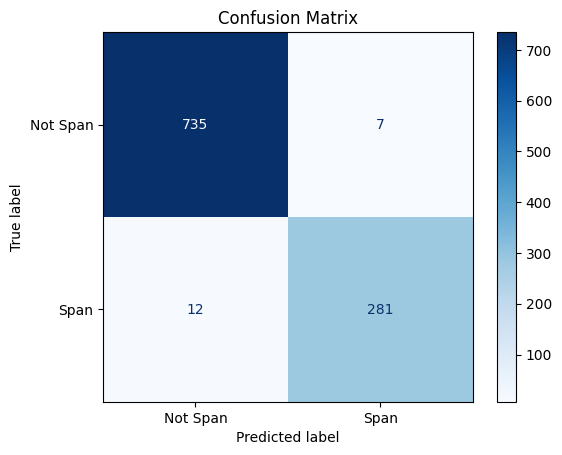

In [114]:
cm = confusion_matrix(y_test,pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Span','Span'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [115]:
print(classification_report(y_test,pred))
#

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       742
           1       0.98      0.96      0.97       293

    accuracy                           0.98      1035
   macro avg       0.98      0.97      0.98      1035
weighted avg       0.98      0.98      0.98      1035



In [116]:
print("Accuracy: ",accuracy_score(y_test,pred))
print("Precision: ",precision_score(y_test,pred))
print("Recall: ",recall_score(y_test,pred))
print("F1 Score: ",f1_score(y_test,pred))
print("ROC AUC Score: ",roc_auc_score(y_test,pred))


Accuracy:  0.9816425120772947
Precision:  0.9756944444444444
Recall:  0.9590443686006825
F1 Score:  0.9672977624784854
ROC AUC Score:  0.9748052031682657


In [117]:
check = pd.DataFrame({'Actual':y_test,'Predicted':pred})
check.head(10)

,Actual,Predicted
1566,0,0
1988,1,1
1235,0,0
2868,0,0
4903,0,0
1471,0,0
1129,0,0
5022,0,0
3048,0,0
530,0,0
